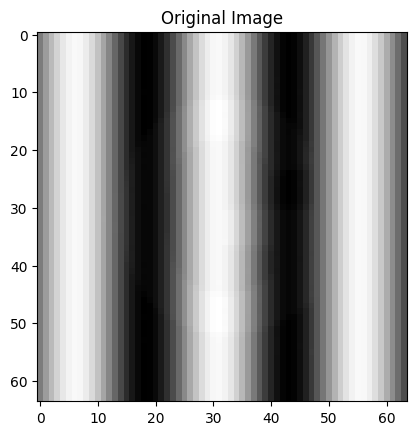

(64, 64)


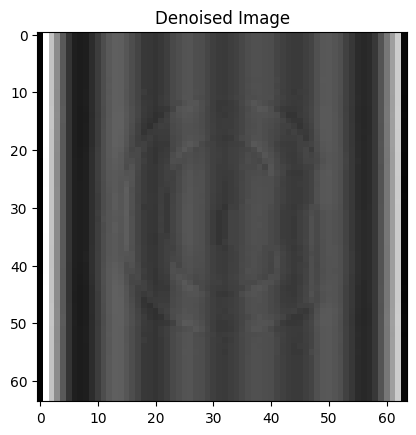

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def fourier_transform(signal, frequencies, sampled_times):
    num_freqs = len(frequencies)
    ft_result_real = np.zeros(num_freqs)
    ft_result_imag = np.zeros(num_freqs)
    
    # Store the fourier transform results for each frequency. Handle the real and imaginary parts separately
    # use trapezoidal integration to calculate the real and imaginary parts of the FT


    
    for i, freq in enumerate(frequencies):
        ft_result_real[i] = np.trapz(signal * np.cos(2 * np.pi * freq * sampled_times),sampled_times)
        ft_result_imag[i] = np.trapz(signal * np.sin(-2 * np.pi * freq * sampled_times),sampled_times)
    
    return ft_result_real, ft_result_imag   

def inverse_fourier_transform(ft_signal, frequencies, sampled_times):
    n = len(sampled_times)
    reconstructed_signal = np.zeros(n)
    ft_real, ft_imag = ft_signal

    for i, t in enumerate(sampled_times):

        real_component =np.sum(ft_signal[0] * np.cos(2 * np.pi * frequencies * t))
        imag_component =np.sum(ft_signal[1]* np.sin(2 * np.pi * frequencies * t))
        reconstructed_signal[i] = (real_component-imag_component) * (frequencies[1]-frequencies[0])

    return reconstructed_signal

# Load and preprocess the image
image = plt.imread('noisy_image.png')  # Replace with your image file path
# show the image
plt.figure()
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.show()

if image.ndim == 3:
    image = np.mean(image, axis=2)  # Convert to grayscale

image = image / 255.0  # Normalize to range [0, 1]
print (image.shape)

sample_rate = 1000 

denoised_image=np.zeros((64,64))



# time = np.linspace(0, len(image[0]) / sample_rate, num=len(image[0]))
# plt.plot(time, image[0])




for i in range(image.shape[0])
    time = np.linspace(0, len(image[i]) / sample_rate, num=len(image[i]))
    interval_step = 1  # Adjust for sampling every 'interval_step' data points  
    data_sampled = image[i][::interval_step]
    max_time = len(data_sampled) / (sample_rate / interval_step)
    sampled_times = np.linspace(0, max_time, num=len(data_sampled))


    max_freq = sample_rate / (2 * interval_step)
    num_freqs = len(data_sampled)
    frequencies = np.linspace(0, max_freq, num=num_freqs)

    ft_data = fourier_transform(data_sampled, frequencies, sampled_times)

    # plt.figure(figsize=(12, 6))
    # plt.plot(frequencies, np.sqrt(ft_data[0]**2 + ft_data[1]**2))

    filtered_ft_data= np.zeros((2, num_freqs))
    filtered_ft_data[0] = ft_data[0].copy()
    filtered_ft_data[1] = ft_data[1].copy()


    mask = (frequencies <75)
    # & (frequencies > 20) & (frequencies < 15)
    filtered_ft_data[0][mask] = 0 
    filtered_ft_data[1][mask] = 0  


    filtered_data = inverse_fourier_transform(filtered_ft_data, frequencies, sampled_times)
    denoised_image[i]=filtered_data


# Set parameters for interval sampling and FT




# plt.figure(figsize=(12, 6))
# plt.plot(frequencies, np.sqrt(ft_data[0]**2 + ft_data[1]**2))
# plt.title("Frequency Spectrum of the Audio Signal (Custom FT with Trapezoidal Integration)")
# plt.xlabel("Frequency (Hz)")
# plt.ylabel("Magnitude")
# plt.show()




# Step 4.2: Plot the reconstructed audio signal
# plt.figure(figsize=(12, 4))
# plt.plot(sampled_times, filtered_data)
# plt.title("Reconstructed (Denoised) Audio Signal (Time Domain)")
# plt.xlabel("Time (s)")
# plt.ylabel("Amplitude")
# plt.show()







plt.imsave('denoised_image.png', denoised_image, cmap='gray')


plt.figure()
plt.title('Denoised Image')
plt.imshow(denoised_image, cmap='gray')
plt.show()
